In [1]:
import gc
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms
from torchvision.datasets import ImageFolder
from tqdm.auto import tqdm

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda:0")
criterion = nn.CrossEntropyLoss()

BASE_DIR = Path('.')
if not (BASE_DIR / 'data').exists() and (Path('Текущий контроль 5-6') / 'data').exists():
    BASE_DIR = Path('Текущий контроль 5-6')
MODELS_DIR = BASE_DIR / 'saved_models'
MODELS_DIR.mkdir(exist_ok=True)

MONKEYS_DIR = BASE_DIR / 'data' / 'monkeys'
CATS_DOGS_DIR = BASE_DIR / 'data' / 'cats_dogs'


In [11]:
import torch
print("cuda:", torch.version.cuda)
print("hip:", torch.version.hip)
print("cuda available:", torch.cuda.is_available())
print("cuda count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda: 12.8
hip: None
cuda available: True
cuda count: 1
NVIDIA GeForce GTX 1650 Ti


In [3]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, device):
    history = {'train_loss': [], 'test_loss': [], 'test_acc': []}
    model.to(device)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        test_loss, test_acc, _, _ = evaluate_model(model, test_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        print(f'epoch {epoch + 1}/{epochs}: train_loss={train_loss:.4f} test_loss={test_loss:.4f} test_acc={test_acc:.4f}')

    return history


def evaluate_model(model, loader, criterion, device):
    model.eval()
    losses = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            losses.append(loss.item() * X_batch.size(0))
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    mean_loss = sum(losses) / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    return mean_loss, acc, np.array(all_targets), np.array(all_preds)


def plot_losses(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['test_loss'], label='test')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def show_predictions(model, loader, class_names, device, n=8):
    model.eval()
    images, targets = next(iter(loader))
    images = images[:n].to(device)
    targets = targets[:n]

    with torch.no_grad():
        preds = model(images).argmax(dim=1).cpu()

    cols = min(n, 4)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, img, y_true, y_pred in zip(axes, images.cpu(), targets, preds):
        if img.shape[0] == 1:
            ax.imshow(img.squeeze(0), cmap='gray')
        else:
            ax.imshow(np.transpose(img.numpy(), (1, 2, 0)))
        ax.set_title(f'true={class_names[int(y_true)]}\npred={class_names[int(y_pred)]}')
        ax.axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


def show_confusion(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def visualize_first_conv(model, sample_batch, device, max_maps=8):
    first_conv = next(module for module in model.modules() if isinstance(module, nn.Conv2d))
    fmap = None

    def hook(_, __, output):
        nonlocal fmap
        fmap = output.detach().cpu()

    handle = first_conv.register_forward_hook(hook)
    model.eval()
    with torch.no_grad():
        model(sample_batch[:1].to(device))
    handle.remove()

    feature_maps = fmap[0, :max_maps]
    fig, axes = plt.subplots(1, len(feature_maps), figsize=(3 * len(feature_maps), 3))
    axes = np.array(axes).reshape(-1)
    for ax, fmap_one in zip(axes, feature_maps):
        ax.imshow(fmap_one, cmap='viridis')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def _resolve_class_root(path):
    path = Path(path)
    if not path.exists():
        return None

    current = path
    while True:
        subdirs = [p for p in current.iterdir() if p.is_dir()]
        if not subdirs:
            return None

        # Если в каждой подпапке уже лежат файлы изображений, это и есть корень классов.
        if all(any(child.is_file() for child in sub.iterdir()) for sub in subdirs):
            return current

        # Если это техническая обертка вида training/training или validation/validation,
        # спускаемся глубже, пока не дойдем до папок классов.
        if len(subdirs) == 1:
            current = subdirs[0]
            continue

        return current

def prepare_imagefolder_loaders(root_dir, image_size=224, batch_size=32, train_ratio=0.8):
    root_dir = Path(root_dir)
    if not root_dir.exists():
        print(f'Каталог не найден: {root_dir}')
        return None, None, None

    transform_train = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
    ])
    transform_test = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
    ])

    train_candidates = ['train', 'training']
    test_candidates = ['test', 'validation', 'valid', 'val']
    train_root = next((_resolve_class_root(root_dir / name) for name in train_candidates if (root_dir / name).exists()), None)
    test_root = next((_resolve_class_root(root_dir / name) for name in test_candidates if (root_dir / name).exists()), None)

    if train_root is not None and test_root is not None:
        train_dataset = ImageFolder(root=train_root, transform=transform_train)
        test_dataset = ImageFolder(root=test_root, transform=transform_test)
        class_names = train_dataset.classes
    else:
        dataset_root = _resolve_class_root(root_dir)
        if dataset_root is None:
            print(f'Не удалось определить структуру классов: {root_dir}')
            return None, None, None
        dataset = ImageFolder(root=dataset_root, transform=transform_train)
        train_size = int(len(dataset) * train_ratio)
        test_size = len(dataset) - train_size
        train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))
        class_names = dataset.classes

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return class_names, train_loader, test_loader


## 1. Классификация предметов одежды (Fashion MNIST)
### 1.1 Решить задачу классификации, не используя сверточные слои


Fashion MLP params: 235146
epoch 1/8: train_loss=0.5479 test_loss=0.4450 test_acc=0.8362
epoch 2/8: train_loss=0.3983 test_loss=0.4077 test_acc=0.8497
epoch 3/8: train_loss=0.3622 test_loss=0.3807 test_acc=0.8636
epoch 4/8: train_loss=0.3376 test_loss=0.3681 test_acc=0.8683
epoch 5/8: train_loss=0.3207 test_loss=0.3556 test_acc=0.8742
epoch 6/8: train_loss=0.3072 test_loss=0.3463 test_acc=0.8734
epoch 7/8: train_loss=0.2940 test_loss=0.3434 test_acc=0.8787
epoch 8/8: train_loss=0.2849 test_loss=0.3343 test_acc=0.8780


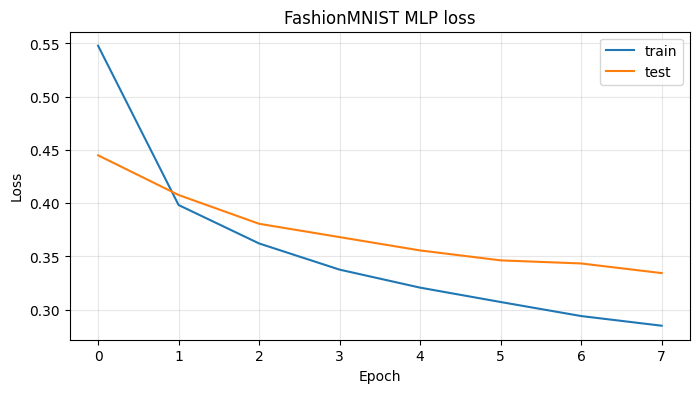

Fashion MLP accuracy: 0.878


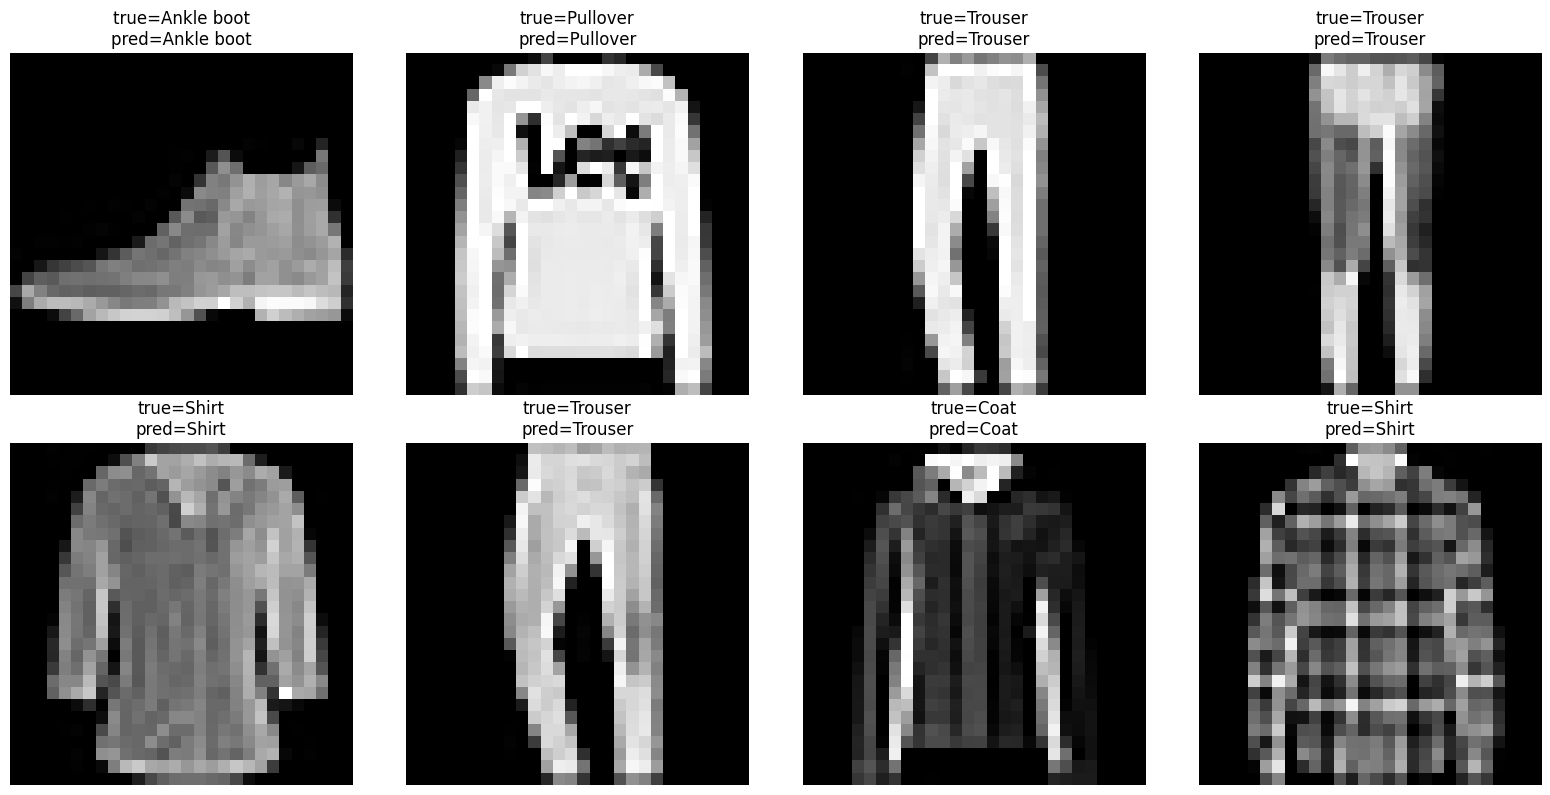

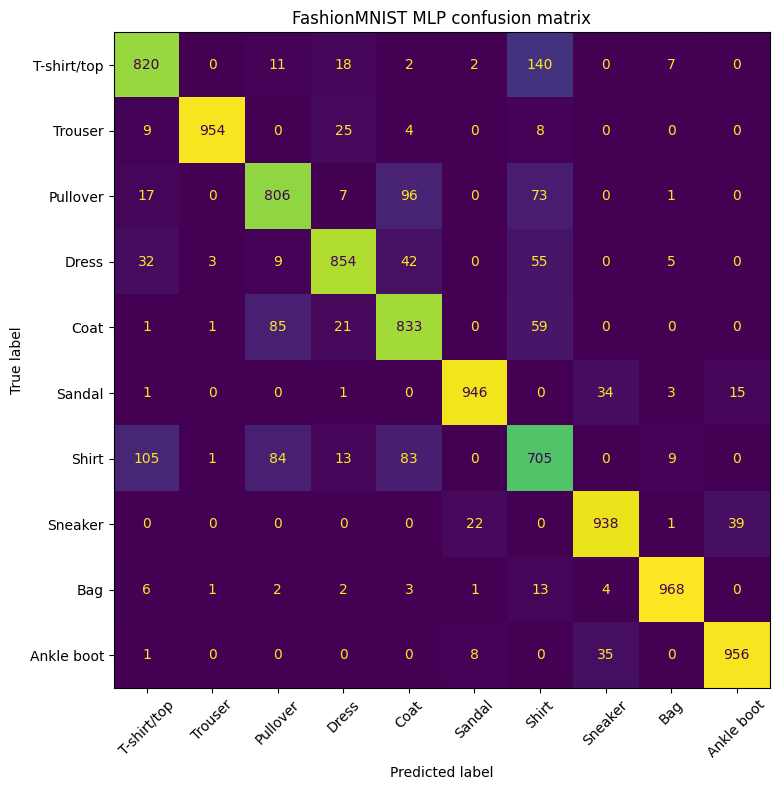

In [4]:
fashion_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

fashion_train = datasets.FashionMNIST(root='data', train=True, download=True, transform=fashion_transform)
fashion_test = datasets.FashionMNIST(root='data', train=False, download=True, transform=fashion_transform)

fashion_train_loader = DataLoader(fashion_train, batch_size=128, shuffle=True)
fashion_test_loader = DataLoader(fashion_test, batch_size=256, shuffle=False)
fashion_classes = fashion_train.classes

class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

fashion_mlp = FashionMLP()
print('Fashion MLP params:', count_parameters(fashion_mlp))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(fashion_mlp.parameters(), lr=1e-3)
history_fashion_mlp = train_model(fashion_mlp, fashion_train_loader, fashion_test_loader, criterion, optimizer, epochs=8, device=device)
plot_losses(history_fashion_mlp, 'FashionMNIST MLP loss')

test_loss, test_acc, y_true, y_pred = evaluate_model(fashion_mlp, fashion_test_loader, criterion, device)
print('Fashion MLP accuracy:', test_acc)
show_predictions(fashion_mlp, fashion_test_loader, fashion_classes, device)
show_confusion(y_true, y_pred, fashion_classes, 'FashionMNIST MLP confusion matrix')
torch.save(fashion_mlp.state_dict(), MODELS_DIR / 'fashion_mlp.pth')


### 1.2 Решить задачу 1.1, используя сверточную нейронную сеть


Fashion CNN params: 421642
epoch 1/8: train_loss=0.5325 test_loss=0.3704 test_acc=0.8658
epoch 2/8: train_loss=0.3456 test_loss=0.3091 test_acc=0.8883
epoch 3/8: train_loss=0.2999 test_loss=0.2853 test_acc=0.8981
epoch 4/8: train_loss=0.2688 test_loss=0.2705 test_acc=0.9029
epoch 5/8: train_loss=0.2427 test_loss=0.2557 test_acc=0.9063
epoch 6/8: train_loss=0.2228 test_loss=0.2435 test_acc=0.9142
epoch 7/8: train_loss=0.2056 test_loss=0.2384 test_acc=0.9136
epoch 8/8: train_loss=0.1898 test_loss=0.2307 test_acc=0.9176


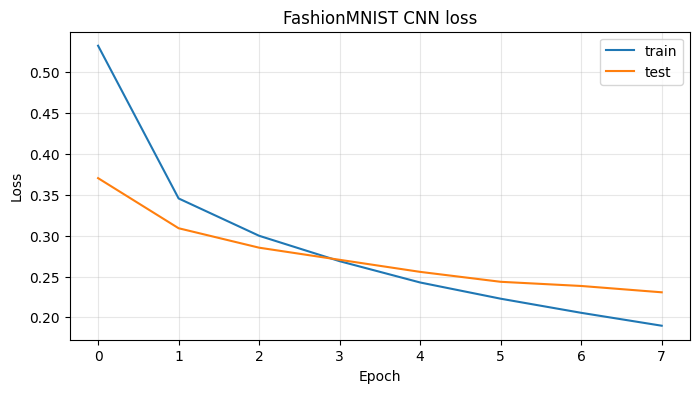

Fashion CNN accuracy: 0.9176


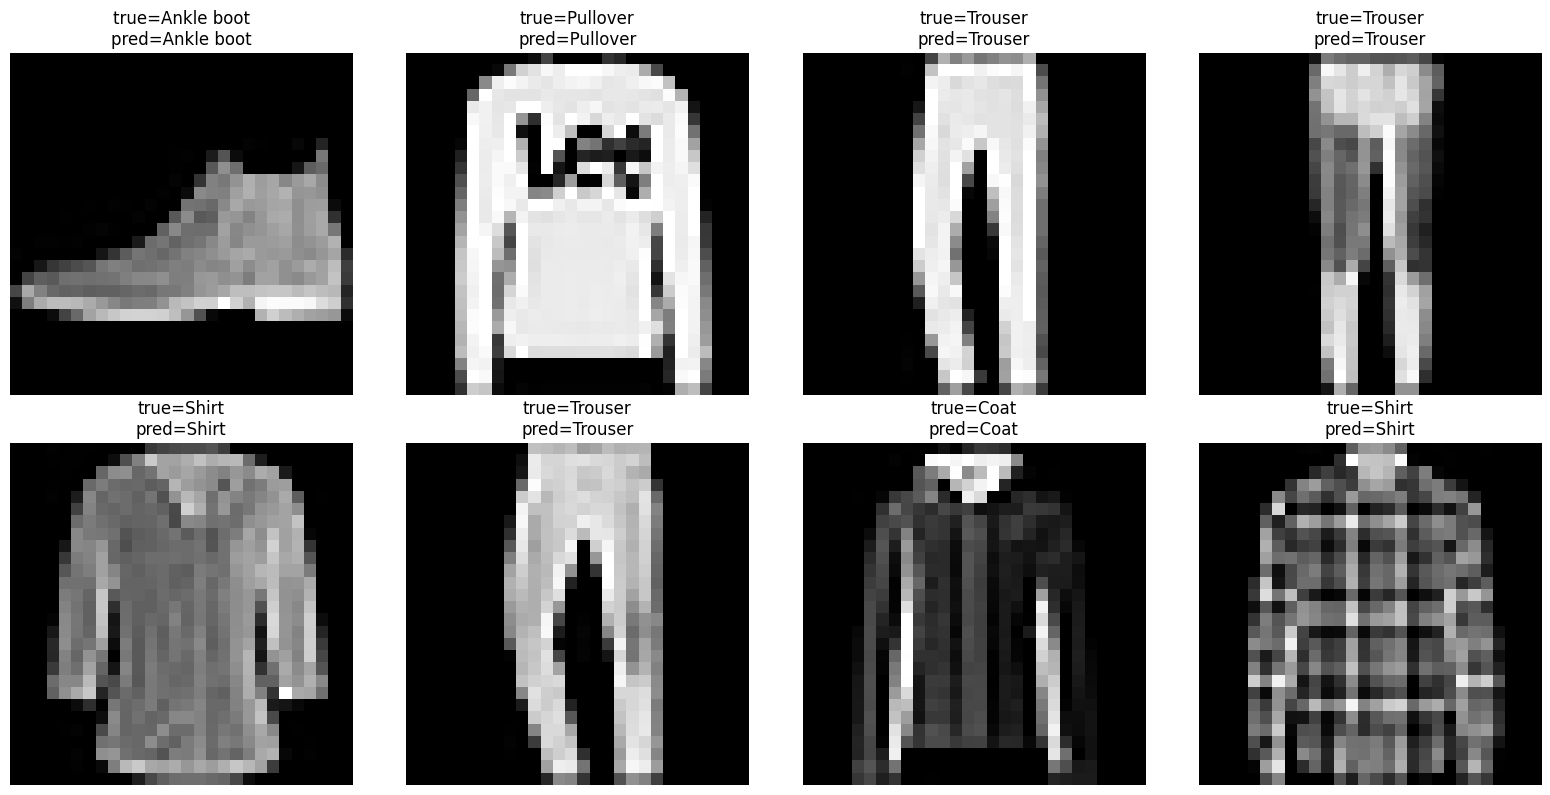

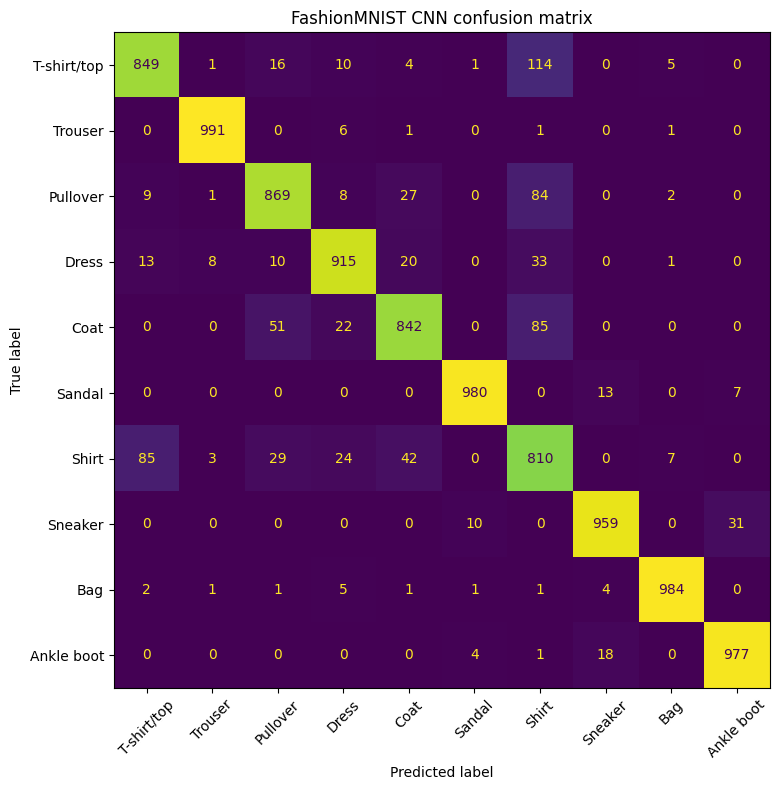

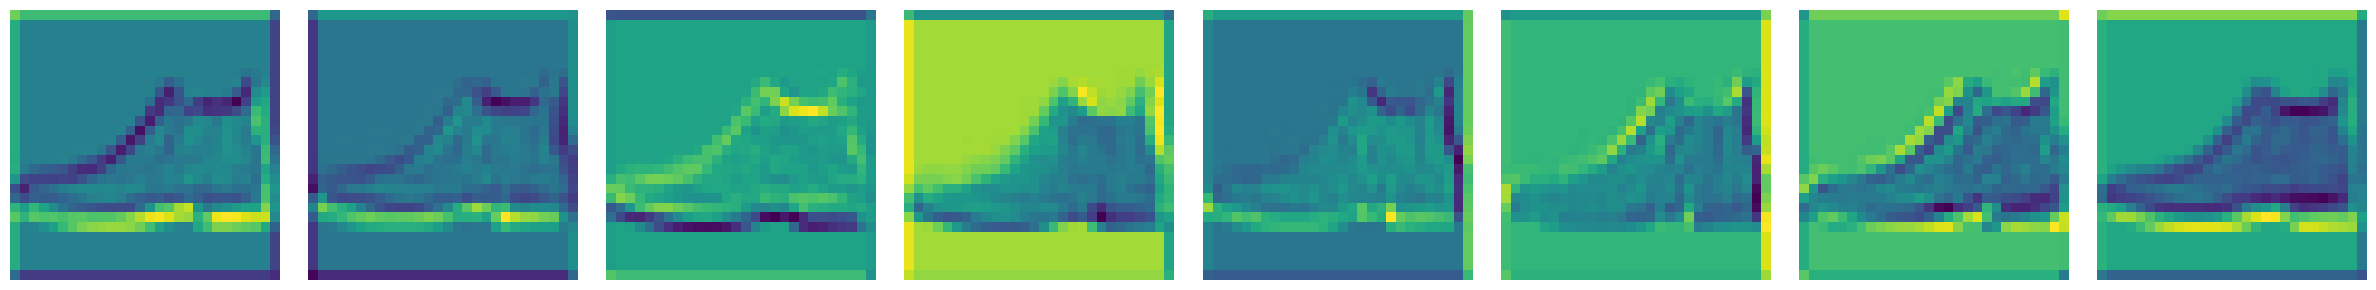

In [5]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

fashion_cnn = FashionCNN()
print('Fashion CNN params:', count_parameters(fashion_cnn))
optimizer = optim.Adam(fashion_cnn.parameters(), lr=1e-3)
history_fashion_cnn = train_model(fashion_cnn, fashion_train_loader, fashion_test_loader, criterion, optimizer, epochs=8, device=device)
plot_losses(history_fashion_cnn, 'FashionMNIST CNN loss')

test_loss, test_acc, y_true, y_pred = evaluate_model(fashion_cnn, fashion_test_loader, criterion, device)
print('Fashion CNN accuracy:', test_acc)
show_predictions(fashion_cnn, fashion_test_loader, fashion_classes, device)
show_confusion(y_true, y_pred, fashion_classes, 'FashionMNIST CNN confusion matrix')
visualize_first_conv(fashion_cnn, next(iter(fashion_test_loader))[0], device)
torch.save(fashion_cnn.state_dict(), MODELS_DIR / 'fashion_cnn.pth')


## 2. Классификация изображений (CIFAR-10)
### 2.1 Решить задачу классификации, не используя сверточные слои


/home/aleksey/Documents/mirea_lab/6 sem/algo-ml/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFAR MLP params: 3411722
epoch 1/10: train_loss=1.6955 test_loss=1.5336 test_acc=0.4561
epoch 2/10: train_loss=1.5177 test_loss=1.4827 test_acc=0.4729
epoch 3/10: train_loss=1.4355 test_loss=1.4363 test_acc=0.5004
epoch 4/10: train_loss=1.3817 test_loss=1.4208 test_acc=0.5011
epoch 5/10: train_loss=1.3281 test_loss=1.4173 test_acc=0.5108
epoch 6/10: train_loss=1.2824 test_loss=1.3775 test_acc=0.5198
epoch 7/10: train_loss=1.2473 test_loss=1.3573 test_acc=0.5238
epoch 8/10: train_loss=1.2040 test_loss=1.3738 test_acc=0.5237
epoch 9/10: train_loss=1.1734 test_loss=1.3841 test_acc=0.5268
epoch 10/10: train_loss=1.1420 test_loss=1.3611 test_acc=0.5343


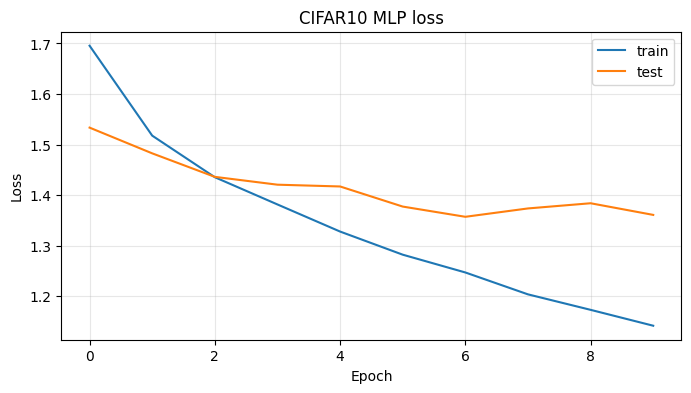

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7830755..2.0985878].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0004883].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9259666..2.075614].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4518033..1.8051611].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8783362..1.5660293].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9198096..1.3605304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9735969

CIFAR MLP accuracy: 0.5343


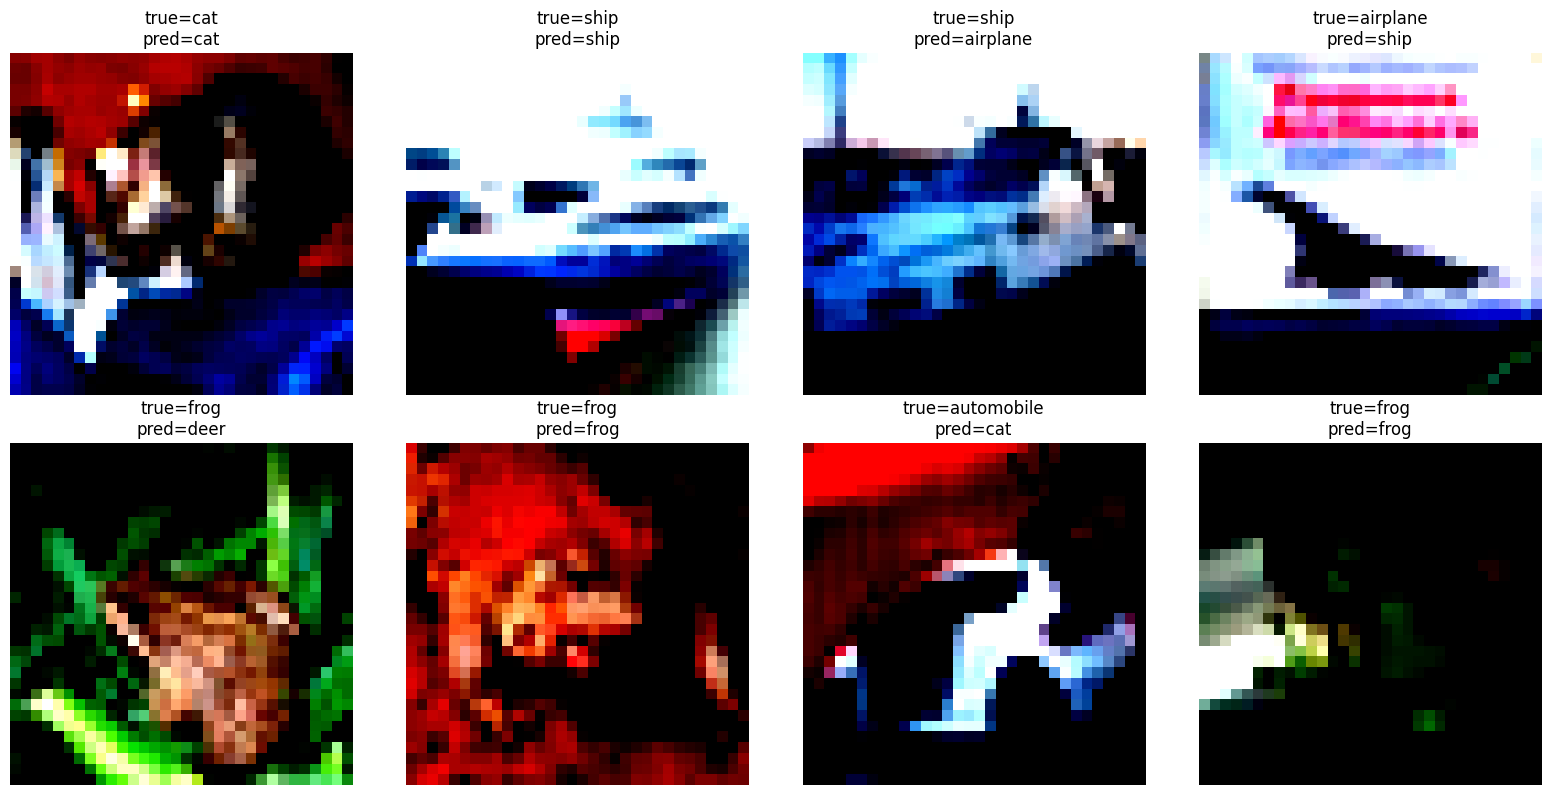

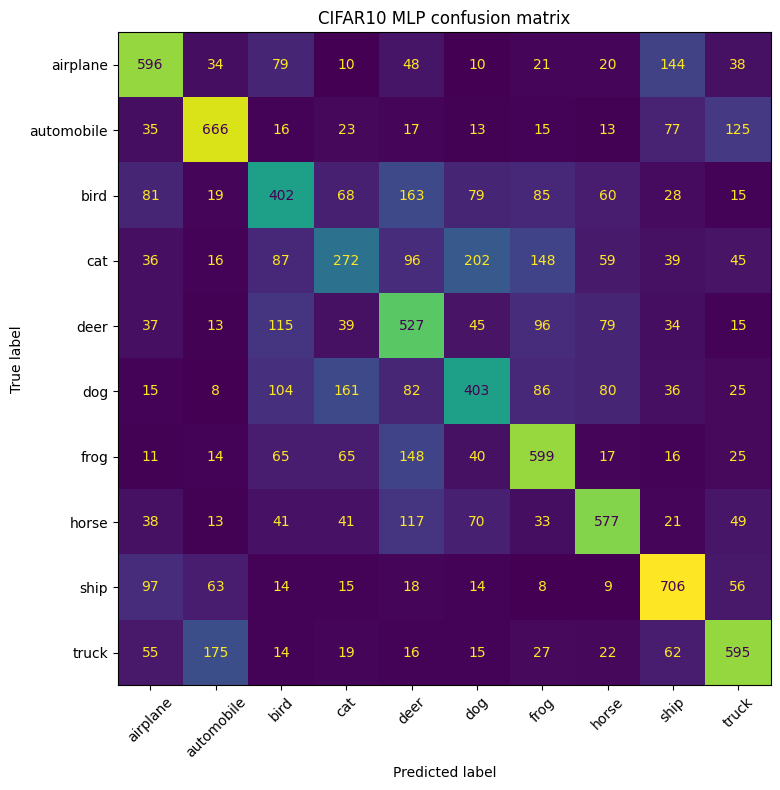

In [6]:
cifar_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])

cifar_train = datasets.CIFAR10(root='data', train=True, download=True, transform=cifar_transform)
cifar_test = datasets.CIFAR10(root='data', train=False, download=True, transform=cifar_transform)

cifar_train_loader = DataLoader(cifar_train, batch_size=128, shuffle=True)
cifar_test_loader = DataLoader(cifar_test, batch_size=256, shuffle=False)
cifar_classes = cifar_train.classes

class CIFARMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.net(x)

cifar_mlp = CIFARMLP()
print('CIFAR MLP params:', count_parameters(cifar_mlp))
optimizer = optim.Adam(cifar_mlp.parameters(), lr=1e-3)
history_cifar_mlp = train_model(cifar_mlp, cifar_train_loader, cifar_test_loader, criterion, optimizer, epochs=10, device=device)
plot_losses(history_cifar_mlp, 'CIFAR10 MLP loss')

test_loss, test_acc, y_true, y_pred = evaluate_model(cifar_mlp, cifar_test_loader, criterion, device)
print('CIFAR MLP accuracy:', test_acc)
show_predictions(cifar_mlp, cifar_test_loader, cifar_classes, device)
show_confusion(y_true, y_pred, cifar_classes, 'CIFAR10 MLP confusion matrix')
torch.save(cifar_mlp.state_dict(), MODELS_DIR / 'cifar_mlp.pth')


### 2.2 Решить задачу 2.1, используя сверточную нейронную сеть


CIFAR CNN params: 2193226
epoch 1/12: train_loss=1.3575 test_loss=1.0221 test_acc=0.6335
epoch 2/12: train_loss=0.9113 test_loss=0.7939 test_acc=0.7206
epoch 3/12: train_loss=0.7326 test_loss=0.7248 test_acc=0.7447
epoch 4/12: train_loss=0.6037 test_loss=0.7152 test_acc=0.7536
epoch 5/12: train_loss=0.4844 test_loss=0.7126 test_acc=0.7639
epoch 6/12: train_loss=0.3956 test_loss=0.7487 test_acc=0.7644
epoch 7/12: train_loss=0.3141 test_loss=0.7921 test_acc=0.7761
epoch 8/12: train_loss=0.2501 test_loss=0.8383 test_acc=0.7675
epoch 9/12: train_loss=0.2020 test_loss=0.9518 test_acc=0.7613
epoch 10/12: train_loss=0.1710 test_loss=0.9388 test_acc=0.7674
epoch 11/12: train_loss=0.1476 test_loss=1.0581 test_acc=0.7640
epoch 12/12: train_loss=0.1337 test_loss=1.0824 test_acc=0.7540


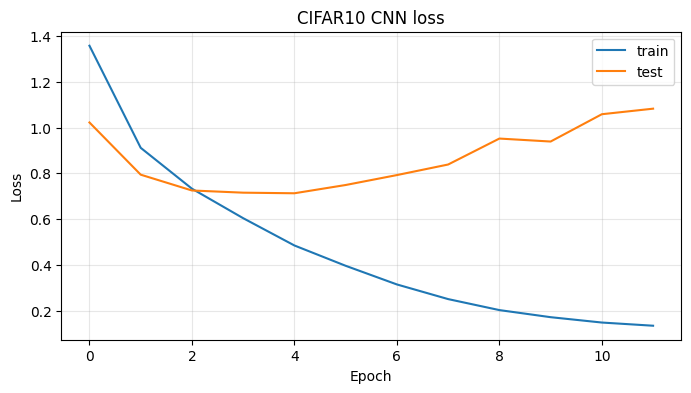

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7830755..2.0985878].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0004883].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9259666..2.075614].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4518033..1.8051611].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8783362..1.5660293].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9198096..1.3605304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9735969

CIFAR CNN accuracy: 0.754


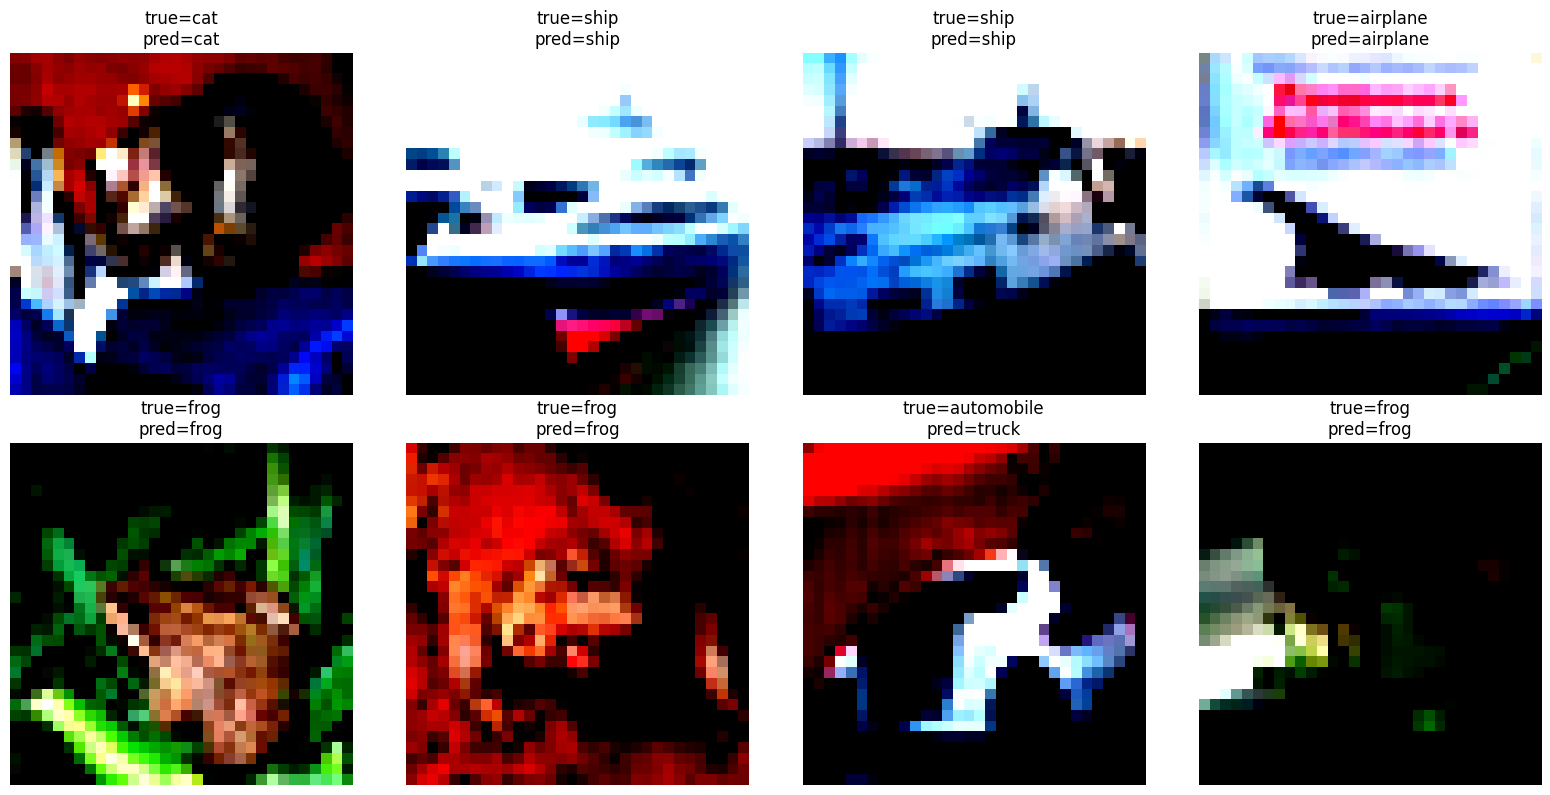

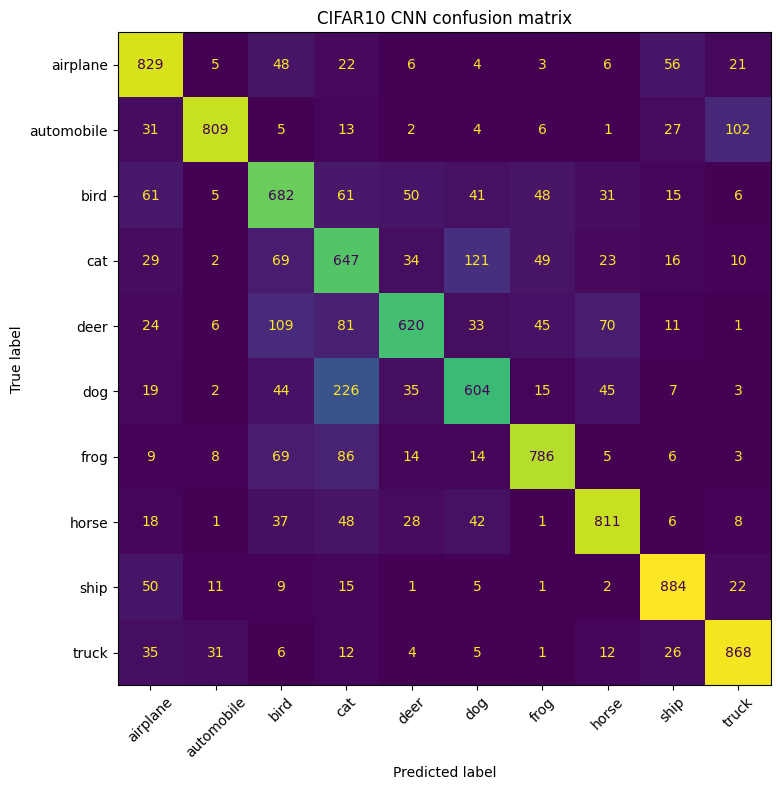

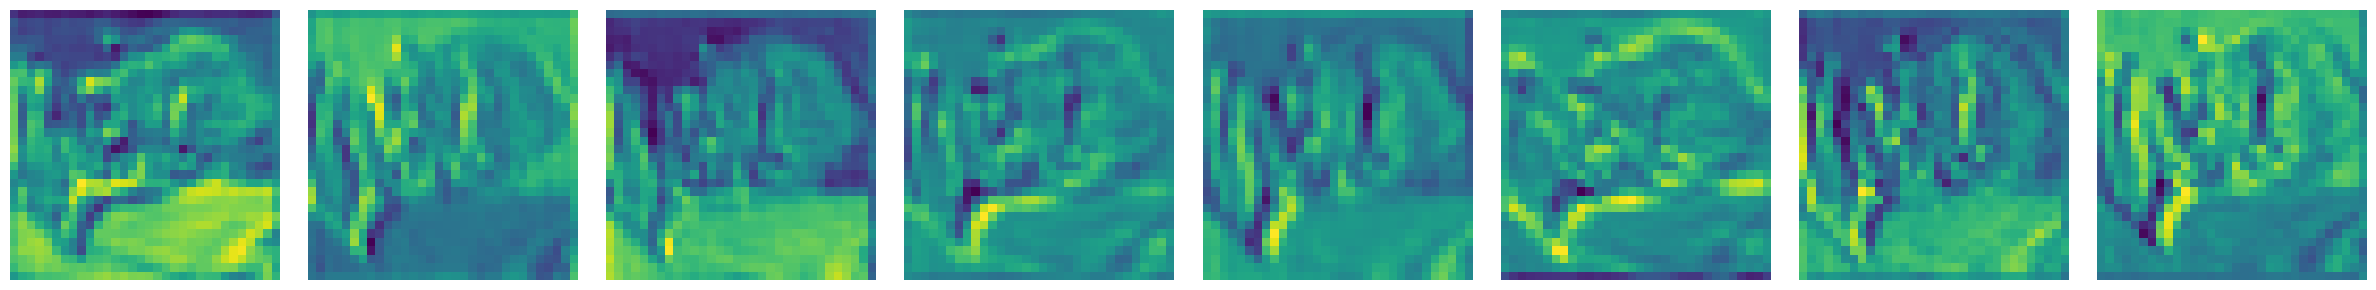

In [7]:
class CIFARCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cifar_cnn = CIFARCNN()
print('CIFAR CNN params:', count_parameters(cifar_cnn))
optimizer = optim.Adam(cifar_cnn.parameters(), lr=1e-3)
history_cifar_cnn = train_model(cifar_cnn, cifar_train_loader, cifar_test_loader, criterion, optimizer, epochs=12, device=device)
plot_losses(history_cifar_cnn, 'CIFAR10 CNN loss')

test_loss, test_acc, y_true, y_pred = evaluate_model(cifar_cnn, cifar_test_loader, criterion, device)
print('CIFAR CNN accuracy:', test_acc)
show_predictions(cifar_cnn, cifar_test_loader, cifar_classes, device)
show_confusion(y_true, y_pred, cifar_classes, 'CIFAR10 CNN confusion matrix')
visualize_first_conv(cifar_cnn, next(iter(cifar_test_loader))[0], device)
torch.save(cifar_cnn.state_dict(), MODELS_DIR / 'cifar_cnn.pth')


## 3. Загрузка изображений из внешних источников
### 3.1 Классификация обезьян через `ImageFolder`


epoch 1/12: train_loss=2.3067 test_loss=2.2976 test_acc=0.1287
epoch 2/12: train_loss=2.2846 test_loss=2.2519 test_acc=0.1875
epoch 3/12: train_loss=2.2244 test_loss=2.1551 test_acc=0.2463
epoch 4/12: train_loss=2.1009 test_loss=2.0897 test_acc=0.2132
epoch 5/12: train_loss=2.0107 test_loss=2.0177 test_acc=0.2904
epoch 6/12: train_loss=2.0090 test_loss=1.9057 test_acc=0.3051
epoch 7/12: train_loss=1.9403 test_loss=1.8654 test_acc=0.3162
epoch 8/12: train_loss=1.9178 test_loss=1.9227 test_acc=0.2537
epoch 9/12: train_loss=1.9404 test_loss=1.8333 test_acc=0.3346
epoch 10/12: train_loss=1.8911 test_loss=1.8036 test_acc=0.3566
epoch 11/12: train_loss=1.9039 test_loss=1.8739 test_acc=0.3015
epoch 12/12: train_loss=1.8376 test_loss=1.7601 test_acc=0.3676


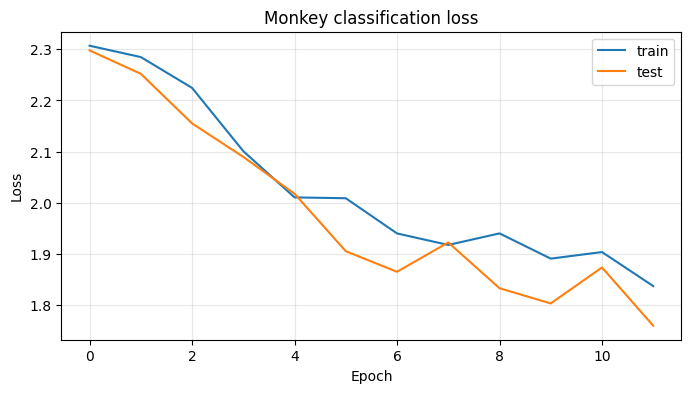

Monkey accuracy: 0.36764705882352944


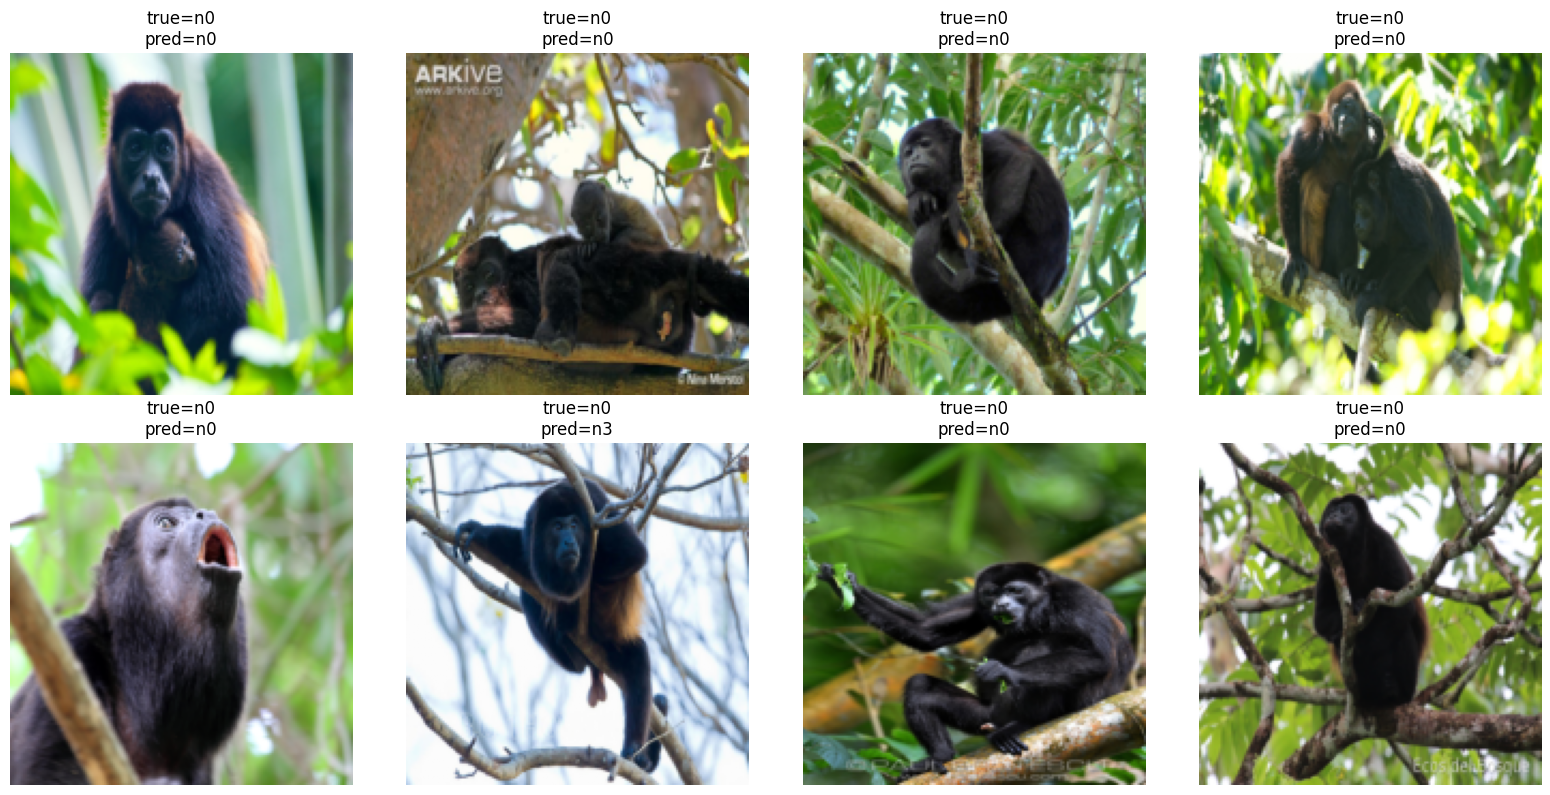

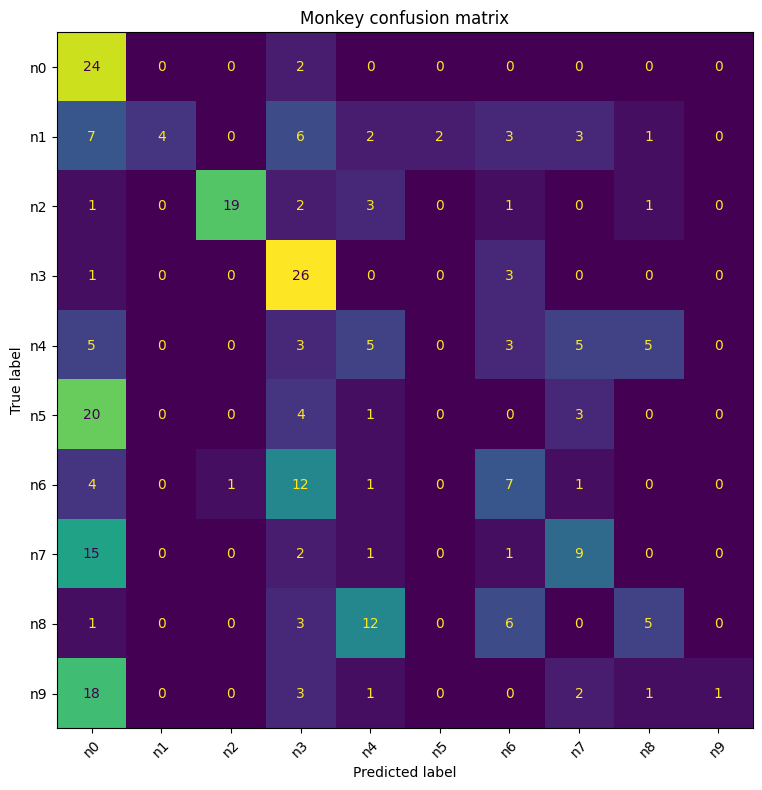

In [8]:
monkey_classes, monkey_train_loader, monkey_test_loader = prepare_imagefolder_loaders(MONKEYS_DIR, image_size=160, batch_size=32)

if monkey_train_loader is not None:
    class MonkeyCNN(nn.Module):
        def __init__(self, n_classes):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool2d((1, 1)),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(64, n_classes),
            )

        def forward(self, x):
            return self.classifier(self.features(x))

    monkey_model = MonkeyCNN(len(monkey_classes))
    optimizer = optim.Adam(monkey_model.parameters(), lr=1e-3)
    history_monkey = train_model(monkey_model, monkey_train_loader, monkey_test_loader, criterion, optimizer, epochs=12, device=device)
    plot_losses(history_monkey, 'Monkey classification loss')
    test_loss, test_acc, y_true, y_pred = evaluate_model(monkey_model, monkey_test_loader, criterion, device)
    print('Monkey accuracy:', test_acc)
    show_predictions(monkey_model, monkey_test_loader, monkey_classes, device)
    show_confusion(y_true, y_pred, monkey_classes, 'Monkey confusion matrix')
    torch.save(monkey_model.state_dict(), MODELS_DIR / 'monkey_cnn.pth')


### 3.2 Классификация собак и кошек через `ImageFolder`


epoch 1/12: train_loss=0.6796 test_loss=0.6605 test_acc=0.5980
epoch 2/12: train_loss=0.6462 test_loss=0.6332 test_acc=0.6430
epoch 3/12: train_loss=0.6141 test_loss=0.5916 test_acc=0.6836
epoch 4/12: train_loss=0.5842 test_loss=0.5488 test_acc=0.7248
epoch 5/12: train_loss=0.5620 test_loss=0.5392 test_acc=0.7296
epoch 6/12: train_loss=0.5463 test_loss=0.5428 test_acc=0.7204
epoch 7/12: train_loss=0.5338 test_loss=0.5112 test_acc=0.7496
epoch 8/12: train_loss=0.5187 test_loss=0.4944 test_acc=0.7626
epoch 9/12: train_loss=0.5126 test_loss=0.4966 test_acc=0.7614
epoch 10/12: train_loss=0.4998 test_loss=0.4804 test_acc=0.7706
epoch 11/12: train_loss=0.4943 test_loss=0.4749 test_acc=0.7742
epoch 12/12: train_loss=0.4775 test_loss=0.4755 test_acc=0.7760


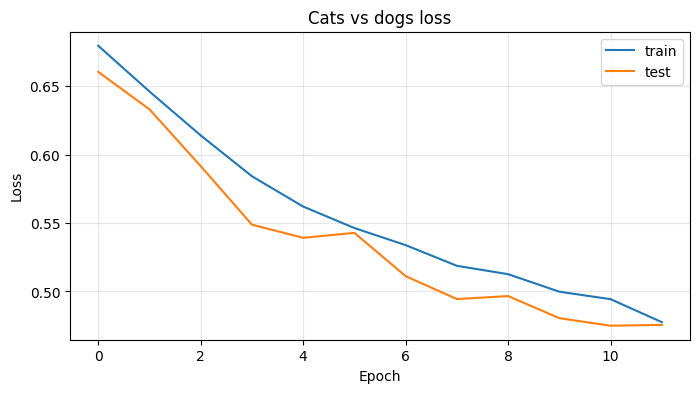

Cats vs dogs accuracy: 0.777


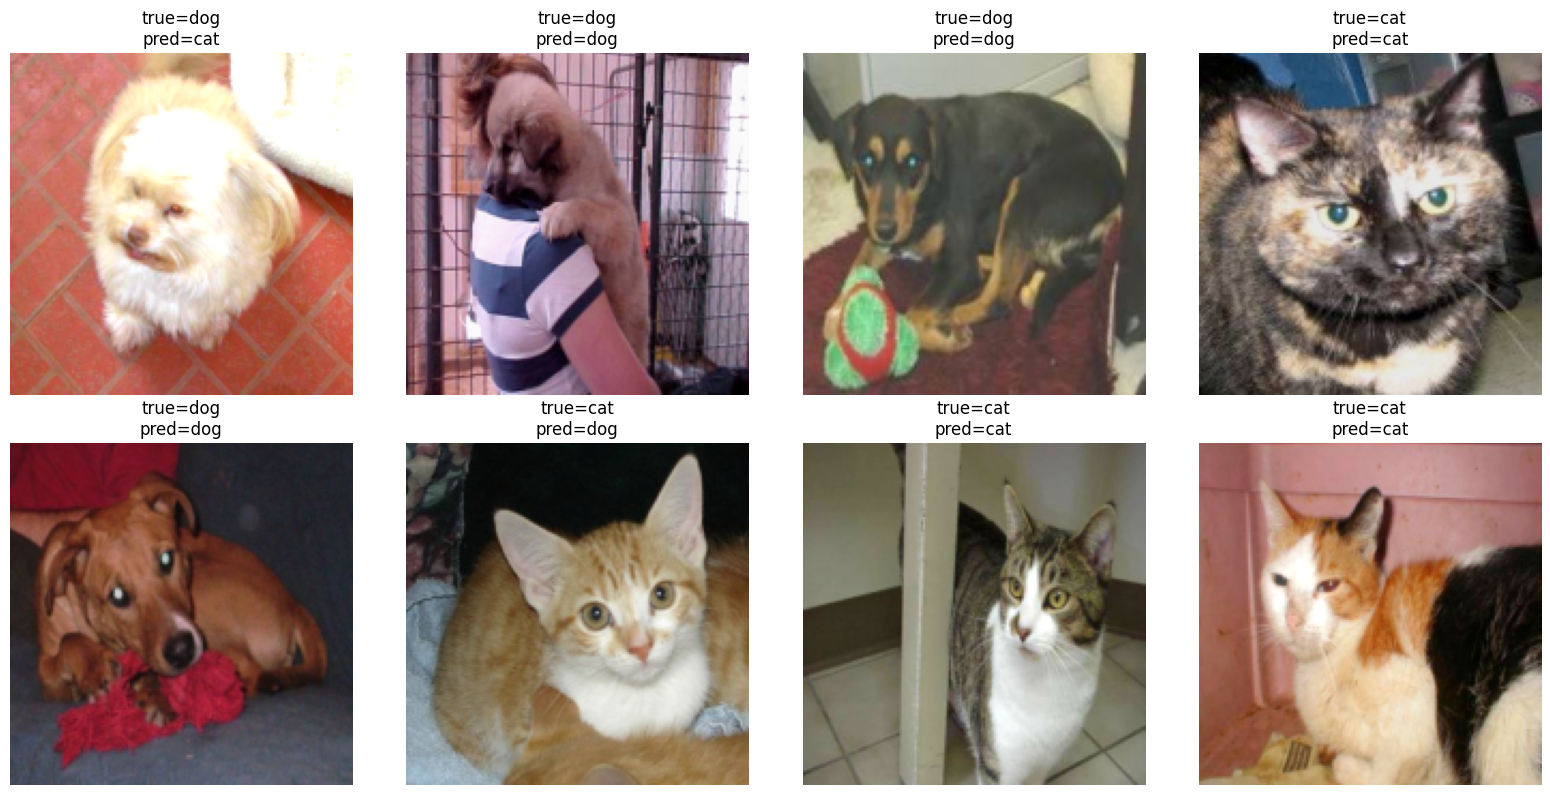

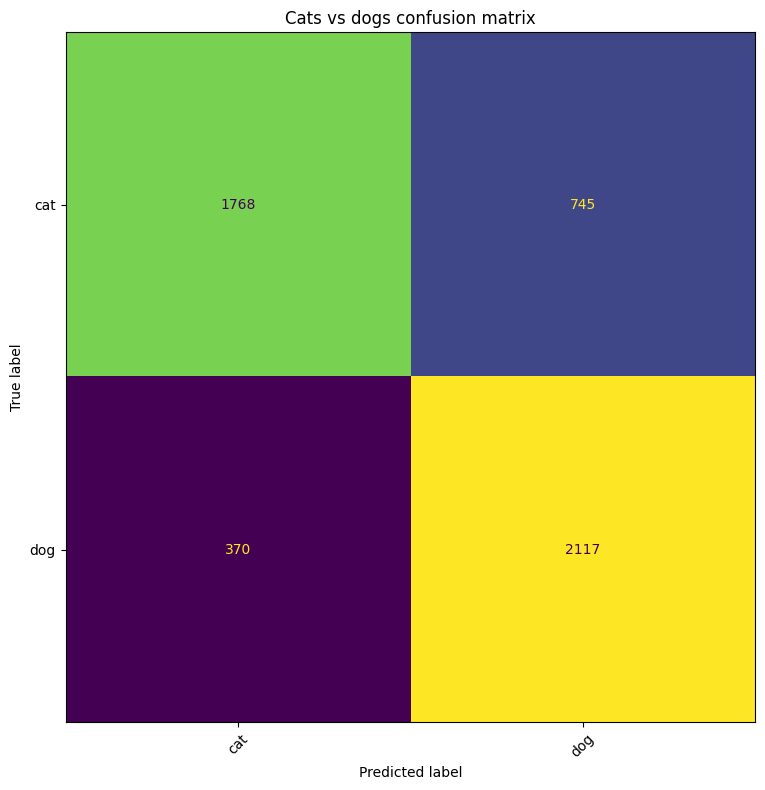

In [9]:
cats_dogs_classes, cats_dogs_train_loader, cats_dogs_test_loader = prepare_imagefolder_loaders(CATS_DOGS_DIR, image_size=160, batch_size=32)

if cats_dogs_train_loader is not None:
    class CatsDogsCNN(nn.Module):
        def __init__(self, n_classes):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool2d((1, 1)),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(64, n_classes),
            )

        def forward(self, x):
            return self.classifier(self.features(x))

    cats_dogs_model = CatsDogsCNN(len(cats_dogs_classes))
    optimizer = optim.Adam(cats_dogs_model.parameters(), lr=1e-3)
    history_cats_dogs = train_model(cats_dogs_model, cats_dogs_train_loader, cats_dogs_test_loader, criterion, optimizer, epochs=12, device=device)
    plot_losses(history_cats_dogs, 'Cats vs dogs loss')
    test_loss, test_acc, y_true, y_pred = evaluate_model(cats_dogs_model, cats_dogs_test_loader, criterion, device)
    print('Cats vs dogs accuracy:', test_acc)
    show_predictions(cats_dogs_model, cats_dogs_test_loader, cats_dogs_classes, device)
    show_confusion(y_true, y_pred, cats_dogs_classes, 'Cats vs dogs confusion matrix')
    torch.save(cats_dogs_model.state_dict(), MODELS_DIR / 'cats_dogs_cnn.pth')


## 4. Transfer Learning
### 4.1 Обезьяны + VGG16


In [4]:
transfer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

def prepare_transfer_loaders(root_dir, batch_size=32, train_ratio=0.8):
    root_dir = Path(root_dir)
    if not root_dir.exists():
        print(f'Каталог не найден: {root_dir}')
        return None, None, None

    train_candidates = ['train', 'training']
    test_candidates = ['test', 'validation', 'valid', 'val']
    train_root = next((_resolve_class_root(root_dir / name) for name in train_candidates if (root_dir / name).exists()), None)
    test_root = next((_resolve_class_root(root_dir / name) for name in test_candidates if (root_dir / name).exists()), None)

    if train_root is not None and test_root is not None:
        train_dataset = ImageFolder(root=train_root, transform=transfer_transform)
        test_dataset = ImageFolder(root=test_root, transform=transfer_transform)
        class_names = train_dataset.classes
    else:
        dataset_root = _resolve_class_root(root_dir)
        if dataset_root is None:
            print(f'Не удалось определить структуру классов: {root_dir}')
            return None, None, None
        dataset = ImageFolder(root=dataset_root, transform=transfer_transform)
        train_size = int(len(dataset) * train_ratio)
        test_size = len(dataset) - train_size
        train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))
        class_names = dataset.classes

    return class_names, DataLoader(train_dataset, batch_size=batch_size, shuffle=True), DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

monkey_classes_tl, monkey_train_tl, monkey_test_tl = prepare_transfer_loaders(MONKEYS_DIR, batch_size=4)

if monkey_train_tl is not None:
    vgg16_full = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    vgg16_full.classifier[-1] = nn.Linear(vgg16_full.classifier[-1].in_features, len(monkey_classes_tl))
    optimizer = optim.Adam(vgg16_full.parameters(), lr=1e-4)
    history_vgg_full = train_model(vgg16_full, monkey_train_tl, monkey_test_tl, criterion, optimizer, epochs=5, device=device)
    _, acc_full, _, _ = evaluate_model(vgg16_full, monkey_test_tl, criterion, device)
    print('VGG16 full fine-tuning accuracy:', acc_full)

    del history_vgg_full
    del vgg16_full
    del optimizer
    gc.collect()
    torch.cuda.empty_cache()

    vgg16_head = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
    for param in vgg16_head.parameters():
        param.requires_grad = False
    for param in vgg16_head.classifier.parameters():
        param.requires_grad = True
    vgg16_head.classifier[-1] = nn.Linear(vgg16_head.classifier[-1].in_features, len(monkey_classes_tl))
    optimizer = optim.Adam(vgg16_head.classifier.parameters(), lr=1e-4)
    history_vgg_head = train_model(vgg16_head, monkey_train_tl, monkey_test_tl, criterion, optimizer, epochs=5, device=device)
    _, acc_head, _, _ = evaluate_model(vgg16_head, monkey_test_tl, criterion, device)
    print('VGG16 classifier-only fine-tuning accuracy:', acc_head)


epoch 1/5: train_loss=0.9300 test_loss=0.3198 test_acc=0.9154
epoch 2/5: train_loss=0.5535 test_loss=0.3022 test_acc=0.9007
epoch 3/5: train_loss=0.2343 test_loss=0.4419 test_acc=0.8934
epoch 4/5: train_loss=0.3658 test_loss=0.2686 test_acc=0.9118
epoch 5/5: train_loss=0.1598 test_loss=0.2433 test_acc=0.9191
VGG16 full fine-tuning accuracy: 0.9301470588235294
epoch 1/5: train_loss=0.3375 test_loss=0.0431 test_acc=0.9853
epoch 2/5: train_loss=0.0917 test_loss=0.0974 test_acc=0.9706
epoch 3/5: train_loss=0.1491 test_loss=0.0715 test_acc=0.9816
epoch 4/5: train_loss=0.1366 test_loss=0.0522 test_acc=0.9816
epoch 5/5: train_loss=0.0728 test_loss=0.0672 test_acc=0.9706
VGG16 classifier-only fine-tuning accuracy: 0.9705882352941176


### 4.2 Собаки и кошки + предобученная модель (ResNet18)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/aleksey/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:05<00:00, 8.10MB/s]


epoch 1/5: train_loss=0.1510 test_loss=0.0650 test_acc=0.9726
epoch 2/5: train_loss=0.0808 test_loss=0.0692 test_acc=0.9740
epoch 3/5: train_loss=0.0581 test_loss=0.0793 test_acc=0.9672
epoch 4/5: train_loss=0.0508 test_loss=0.0621 test_acc=0.9776
epoch 5/5: train_loss=0.0436 test_loss=0.0476 test_acc=0.9820


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.30042..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5356624..2.235994].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


ResNet18 cats vs dogs accuracy: 0.9834


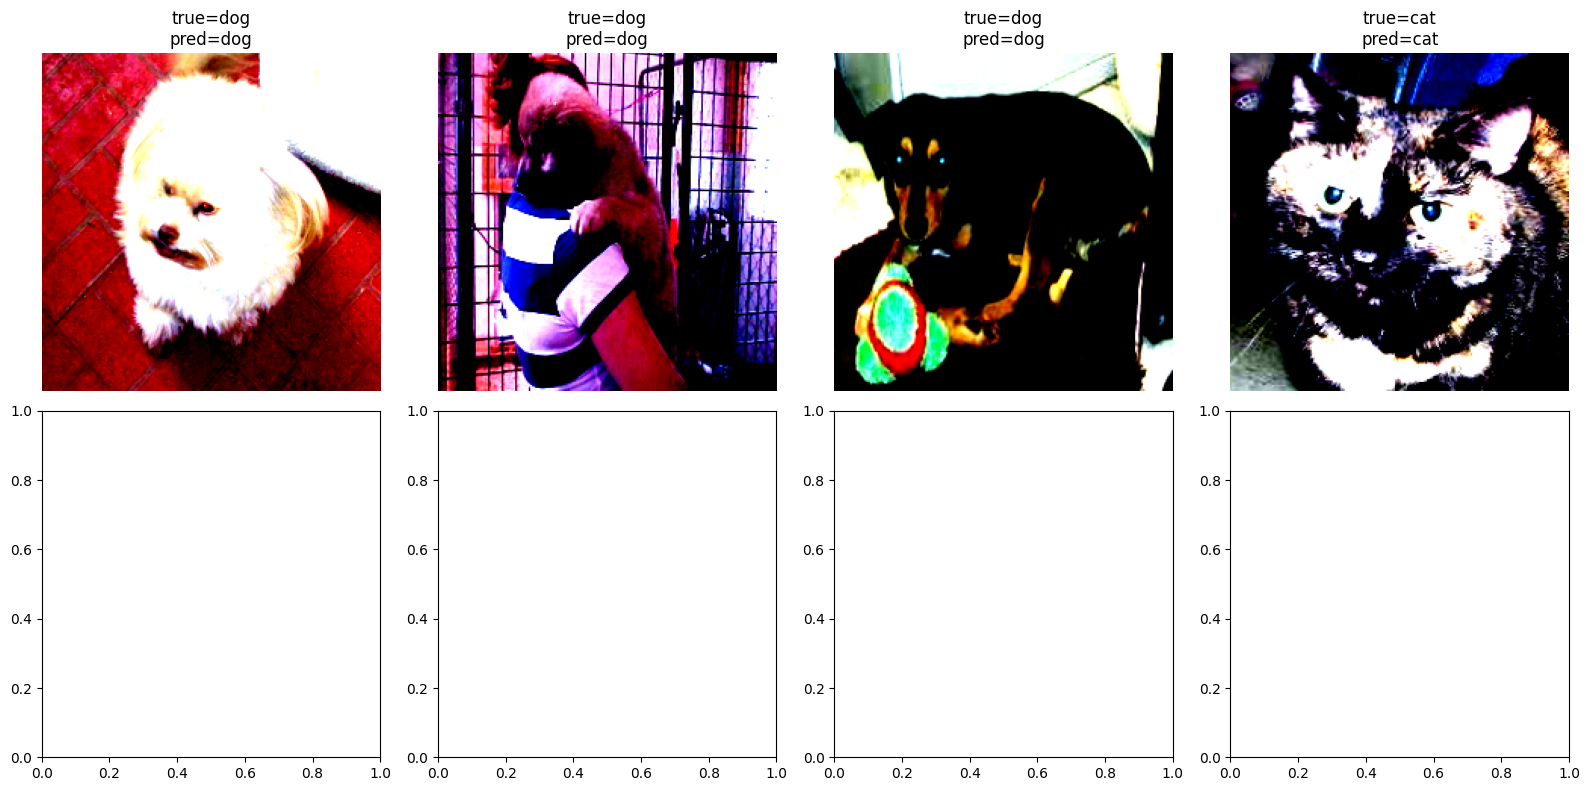

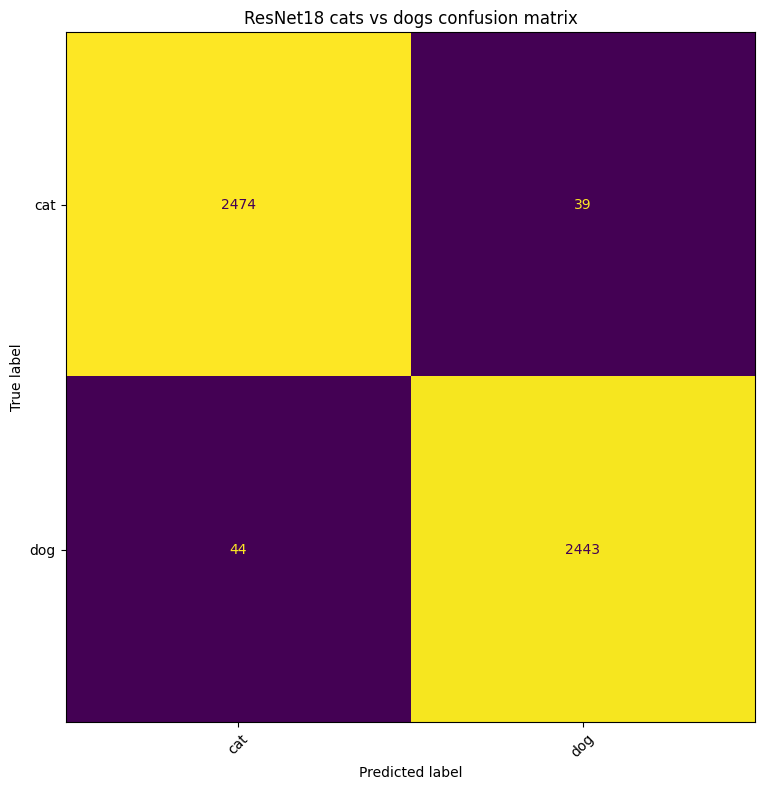

In [5]:
cats_dogs_classes_tl, cats_dogs_train_tl, cats_dogs_test_tl = prepare_transfer_loaders(CATS_DOGS_DIR, batch_size=4)

if cats_dogs_train_tl is not None:
    resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    resnet18.fc = nn.Linear(resnet18.fc.in_features, len(cats_dogs_classes_tl))
    optimizer = optim.Adam(resnet18.parameters(), lr=1e-4)
    history_resnet = train_model(resnet18, cats_dogs_train_tl, cats_dogs_test_tl, criterion, optimizer, epochs=5, device=device)
    _, acc_resnet, y_true, y_pred = evaluate_model(resnet18, cats_dogs_test_tl, criterion, device)
    print('ResNet18 cats vs dogs accuracy:', acc_resnet)
    show_predictions(resnet18, cats_dogs_test_tl, cats_dogs_classes_tl, device)
    show_confusion(y_true, y_pred, cats_dogs_classes_tl, 'ResNet18 cats vs dogs confusion matrix')
